In [14]:
import pandas as pd
df=pd.read_csv('/workspaces/BlizzardX/Data/cleaned_data.csv')

In [15]:
import sys
sys.path.append('/workspaces/BlizzardX')

In [16]:
from src.Model.feature_engineering import FeatureEngineering , ColdEventDetector
fe=FeatureEngineering(df)
ce =ColdEventDetector(fe.apply_all_features())

In [17]:
df=ce.apply_cold_event_detection()

In [18]:
df

,DATE,Station_ID,LATITUDE,LONGITUDE,ELEVATION,NAME,Season,TMIN,TMAX,PRCP,...,Snowfall_Intensity,SNWD_Snowfall_Diff,PRCP_Lag1,PRCP_Lag2,Cumulative_Precipitation_7,Rolling_Sum_PRCP_14,TMAX_PRCP_Interaction,TMIN_SNOW_Interaction,PRCP_SNOW_Interaction,Cold_Event
0,2008-07-01,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,15.60,28.3,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
1,2008-07-02,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,15.60,30.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
2,2008-07-03,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,12.80,27.8,8.10,...,0.00,0.00,0.00,0.00,8.10,8.10,225.18,0.00,0.00,1
3,2008-07-04,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,16.10,30.6,16.30,...,0.00,0.00,8.10,0.00,24.40,24.40,498.78,0.00,0.00,0
4,2008-07-05,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,16.10,22.8,0.00,...,0.00,0.00,16.30,8.10,24.40,24.40,0.00,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53881,2025-04-11,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,-13.90,-6.1,1.00,...,0.08,151.92,0.50,13.20,32.00,92.85,-6.10,-180.70,13.00,0
53882,2025-04-12,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,-11.67,-4.8,1.43,...,0.10,151.90,1.00,0.50,33.43,84.88,-6.86,-178.90,21.92,0
53883,2025-04-13,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,-9.43,-3.5,1.87,...,0.12,151.88,1.43,1.00,19.30,83.15,-6.54,-166.63,33.04,0
53884,2025-04-14,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,-7.20,-2.2,2.30,...,0.13,151.87,1.87,1.43,20.60,71.25,-5.06,-144.00,46.00,0


In [19]:
df.to_csv('/workspaces/BlizzardX/Data/feature_data.csv', index=False)

In [20]:
df[df['Cold_Event'] == 1]['Cold_Event'].count(),df[df['Cold_Event'] == 0]['Cold_Event'].count()

(np.int64(12348), np.int64(41538))

In [21]:
import pandas as pd
df=pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

In [22]:
import sys
sys.path.append('/workspaces/BlizzardX/src')  # add path to src/

from Model.prophet_model import ProphetForecaster  # import class


In [ ]:
# Step 1: Import the class
#from src.Model.prophet_model import ProphetForecaster

# Step 2: Create an instance of the forecaster
forecaster = ProphetForecaster(data_path="/workspaces/BlizzardX/Data/feature_data.csv")

# Step 3: Load and preprocess the data
forecaster.load_and_prepare_data()

# Step 4: Train models on all stations
results_df = forecaster.run_all_stations()

# Step 5: View results
print(results_df.head())


Processing Station: USW00014755
Processing Station: USC00278614


16:10:30 - cmdstanpy - INFO - Chain [1] start processing
16:10:31 - cmdstanpy - INFO - Chain [1] done processing
16:10:33 - cmdstanpy - INFO - Chain [1] start processing
16:10:36 - cmdstanpy - INFO - Chain [1] start processing
16:10:36 - cmdstanpy - INFO - Chain [1] done processing
16:10:40 - cmdstanpy - INFO - Chain [1] start processing
16:10:40 - cmdstanpy - INFO - Chain [1] done processing
16:10:41 - cmdstanpy - INFO - Chain [1] done processing
16:10:44 - cmdstanpy - INFO - Chain [1] start processing
16:10:44 - cmdstanpy - INFO - Chain [1] done processing
16:10:48 - cmdstanpy - INFO - Chain [1] start processing
16:10:49 - cmdstanpy - INFO - Chain [1] done processing
16:10:50 - cmdstanpy - INFO - Chain [1] start processing
16:10:52 - cmdstanpy - INFO - Chain [1] start processing
16:10:53 - cmdstanpy - INFO - Chain [1] done processing
16:10:58 - cmdstanpy - INFO - Chain [1] start processing
16:10:58 - cmdstanpy - INFO - Chain [1] done processing
16:10:58 - cmdstanpy - INFO - Chain [1]


📈 Forecast Results for Station USC00272302 (Test Data):
        ds     y   yhat  yhat_lower  yhat_upper
2025-01-01  -1.7  -2.35       -3.53       -1.17
2025-01-02   0.6  -0.36       -1.49        0.77
2025-01-03  -1.1  -1.05       -2.18        0.10
2025-01-04  -6.1  -5.63       -6.77       -4.44
2025-01-05  -6.1  -6.63       -7.83       -5.52
2025-01-06 -10.6 -10.82      -11.89       -9.70
2025-01-07 -10.6  -9.97      -11.07       -8.78
2025-01-08  -8.9  -7.42       -8.59       -6.37
2025-01-09 -10.0  -8.91      -10.04       -7.78
2025-01-10  -8.3  -7.77       -8.96       -6.64
2025-01-11  -8.3  -7.56       -8.79       -6.42
2025-01-12 -10.6 -11.79      -12.93      -10.71
2025-01-13 -10.0 -12.83      -13.99      -11.71
2025-01-14  -9.4 -10.94      -12.07       -9.82
2025-01-15  -7.8  -7.04       -8.20       -5.89
2025-01-16 -15.0 -14.36      -15.42      -13.21
2025-01-17 -15.0 -14.04      -15.15      -12.86
2025-01-18 -13.3 -13.79      -15.03      -12.71
2025-01-19  -5.6  -6.71       -

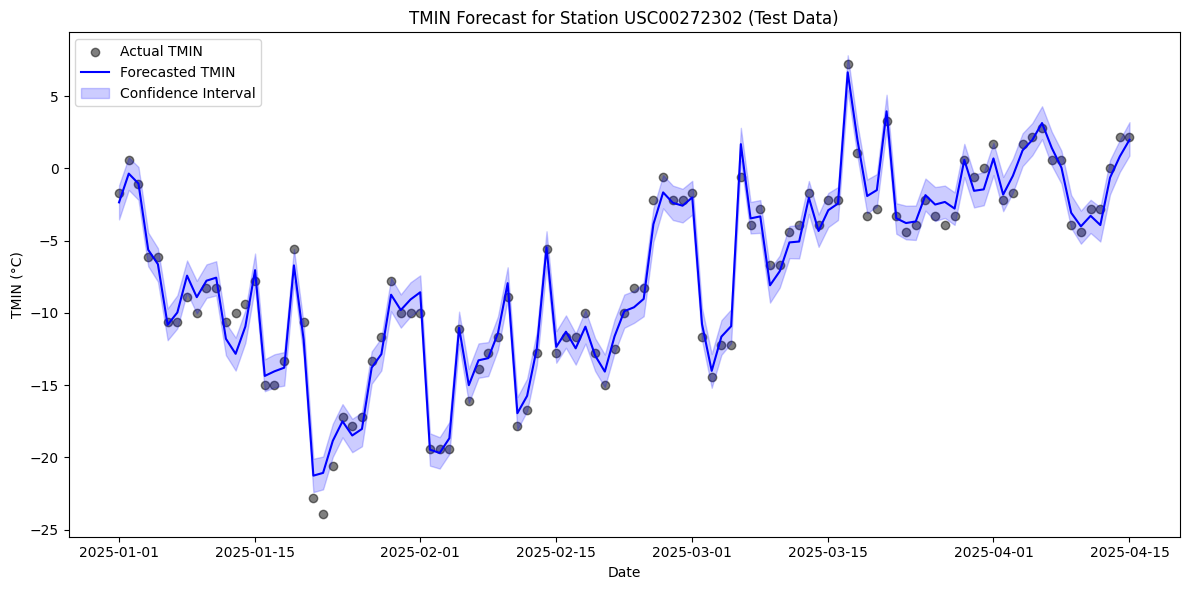


📈 Forecast Results for Station USC00279278 (Test Data):
        ds      y   yhat  yhat_lower  yhat_upper
2025-01-01  -1.10  -1.86       -2.96       -0.81
2025-01-02   1.10   0.10       -1.03        1.19
2025-01-03  -1.10   0.00       -1.13        1.14
2025-01-04  -4.40  -3.63       -4.80       -2.54
2025-01-05  -7.20  -7.06       -8.21       -5.94
2025-01-06 -10.60 -10.53      -11.63       -9.39
2025-01-07 -10.60 -10.40      -11.47       -9.26
2025-01-08  -8.30  -7.29       -8.37       -6.15
2025-01-09 -10.60  -9.65      -10.76       -8.54
2025-01-10  -8.30  -8.84       -9.99       -7.76
2025-01-11  -5.60  -5.78       -6.87       -4.70
2025-01-12  -6.70  -8.90       -9.98       -7.74
2025-01-13  -8.30 -11.52      -12.60      -10.48
2025-01-14  -8.30  -9.68      -10.78       -8.52
2025-01-15  -7.20  -6.22       -7.33       -5.13
2025-01-16 -14.40 -13.66      -14.86      -12.57
2025-01-17 -12.80 -11.85      -12.93      -10.67
2025-01-18 -10.00 -10.12      -11.30       -9.00
2025-01-19  

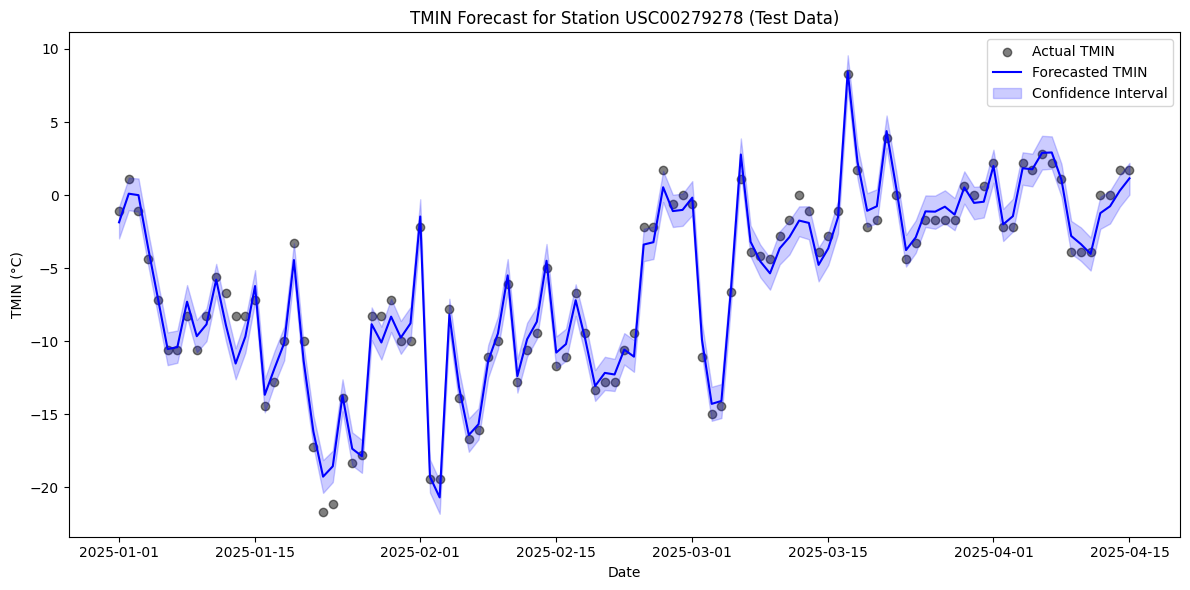


📈 Forecast Results for Station USC00278614 (Test Data):
        ds     y   yhat  yhat_lower  yhat_upper
2025-01-01  -2.8  -5.01       -6.24       -3.86
2025-01-02   0.6  -1.09       -2.26        0.14
2025-01-03  -2.2  -2.30       -3.47       -1.07
2025-01-04  -7.8  -7.80       -8.92       -6.72
2025-01-05  -8.3  -9.83      -10.97       -8.58
2025-01-06 -13.9 -14.97      -16.15      -13.81
2025-01-07 -12.8 -13.73      -14.95      -12.53
2025-01-08  -8.9  -8.05       -9.30       -6.85
2025-01-09 -10.6  -9.83      -10.93       -8.65
2025-01-10  -8.3  -8.95      -10.08       -7.84
2025-01-11  -6.7  -6.31       -7.49       -5.14
2025-01-12 -10.0 -11.60      -12.77      -10.50
2025-01-13 -10.0 -13.22      -14.41      -12.09
2025-01-14  -9.4 -10.84      -11.99       -9.67
2025-01-15  -7.8  -7.07       -8.15       -6.02
2025-01-16 -17.2 -16.28      -17.53      -15.07
2025-01-17 -17.2 -15.62      -16.79      -14.46
2025-01-18 -13.3 -12.21      -13.44      -11.06
2025-01-19  -5.0  -4.53       -

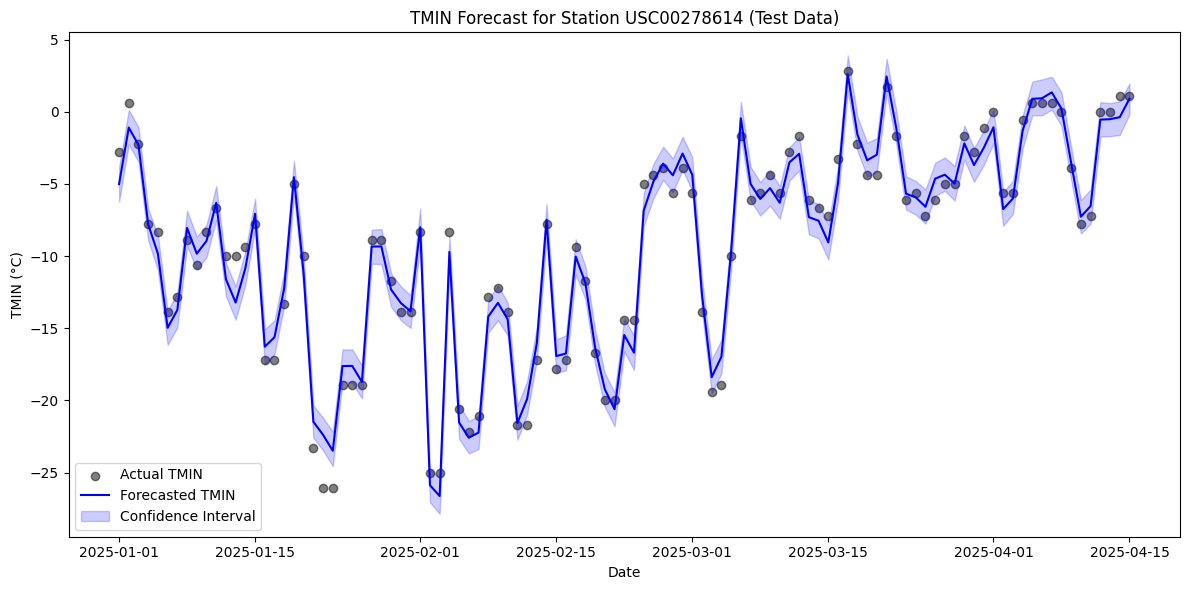


📈 Forecast Results for Station USC00275703 (Test Data):
        ds     y   yhat  yhat_lower  yhat_upper
2025-01-01  -2.2  -3.59       -5.17       -2.10
2025-01-02   0.6  -0.32       -1.85        1.24
2025-01-03  -1.7  -2.78       -4.27       -1.29
2025-01-04  -7.8  -9.57      -11.01       -7.99
2025-01-05  -6.7  -8.81      -10.31       -7.26
2025-01-06 -10.6 -10.39      -11.95       -8.79
2025-01-07 -11.7 -10.09      -11.67       -8.41
2025-01-08 -10.6  -7.38       -8.86       -5.88
2025-01-09 -11.1  -9.02      -10.55       -7.46
2025-01-10  -8.9  -9.31      -10.80       -7.72
2025-01-11  -6.7  -6.56       -8.13       -4.97
2025-01-12 -10.0 -11.45      -12.92       -9.96
2025-01-13 -10.6 -13.13      -14.68      -11.56
2025-01-14 -11.1 -11.18      -12.82       -9.63
2025-01-15  -7.8  -6.86       -8.18       -5.26
2025-01-16 -16.1 -14.95      -16.50      -13.31
2025-01-17 -16.1 -14.76      -16.37      -13.13
2025-01-18 -12.8 -12.79      -14.31      -11.28
2025-01-19  -4.4  -5.38       -

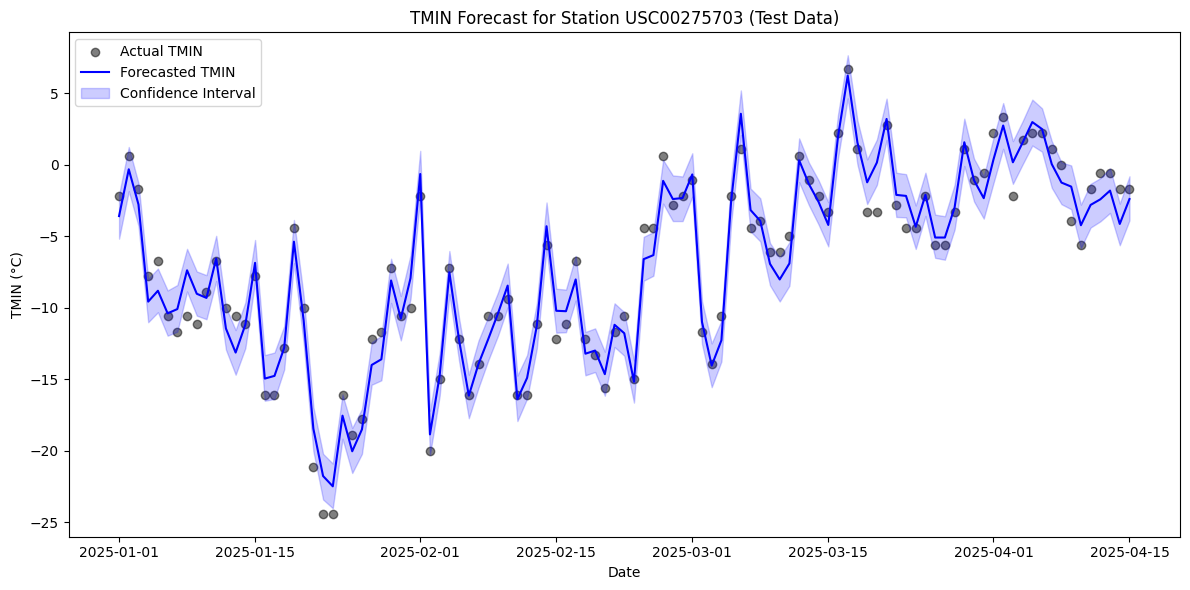


📈 Forecast Results for Station USW00014755 (Test Data):
        ds      y   yhat  yhat_lower  yhat_upper
2025-01-01  -7.20  -8.03       -8.77       -7.28
2025-01-02 -13.90 -14.20      -14.93      -13.41
2025-01-03 -17.80 -19.28      -20.04      -18.41
2025-01-04 -23.30 -24.51      -25.24      -23.68
2025-01-05 -23.90 -23.69      -24.46      -22.93
2025-01-06 -13.90 -14.34      -15.15      -13.56
2025-01-07 -24.40 -23.87      -24.62      -23.08
2025-01-08 -23.90 -22.86      -23.64      -22.03
2025-01-09 -24.40 -24.25      -25.05      -23.47
2025-01-10 -17.80 -17.45      -18.23      -16.63
2025-01-11 -11.70 -11.44      -12.22      -10.64
2025-01-12 -16.70 -17.30      -18.10      -16.54
2025-01-13 -13.30 -14.65      -15.46      -13.86
2025-01-14 -16.10 -16.57      -17.34      -15.77
2025-01-15 -22.20 -21.84      -22.64      -21.13
2025-01-16 -22.20 -21.07      -21.88      -20.30
2025-01-17 -20.00 -19.01      -19.78      -18.20
2025-01-18 -16.10 -16.04      -16.86      -15.24
2025-01-19 -

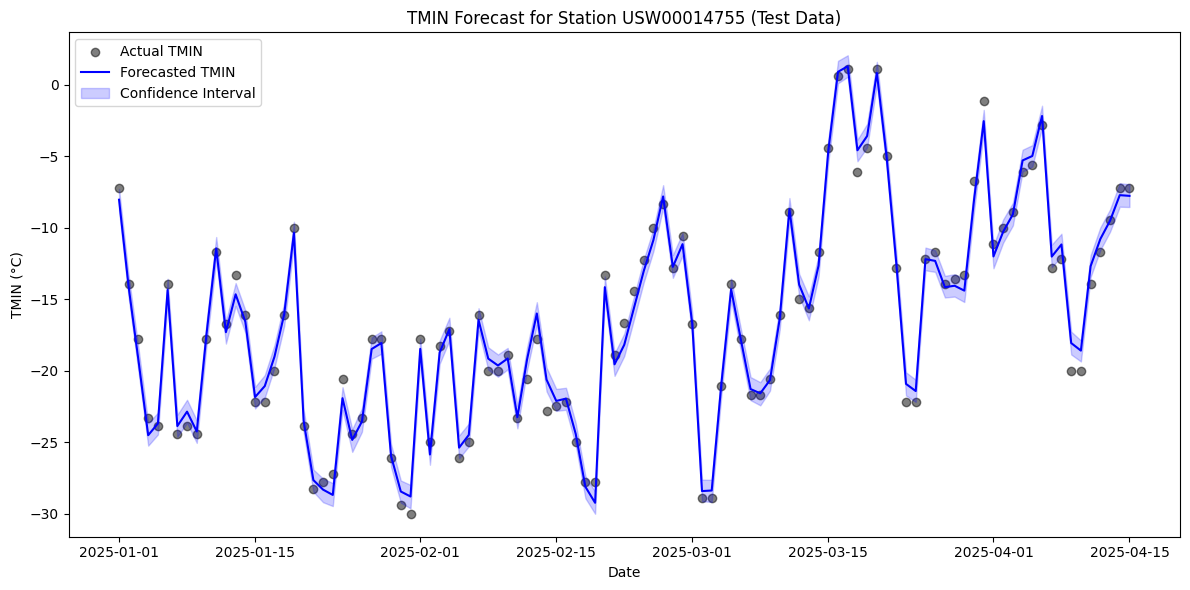

In [ ]:
for station in ["USC00272302","USC00279278","USC00278614","USC00275703","USW00014755"]:
    forecaster.plot_station_forecast(station)

In [1]:
pip install keras-tuner

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import Input
import keras_tuner as kt
from keras_tuner import Objective
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import multiprocessing
import os

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load and filter data
data = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
station_id = 'USC00279278'
data = data[data['Station_ID'] == station_id]

# Feature selection
initial_features = [
    'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
    'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'Seasonal_TMIN_Anomaly',
    'TMIN_Lag1', 'PRCP_Lag1', 'Cumulative_Precipitation_7',
    'Day_of_Year', 'Month'
]

data = data.dropna().sort_values('DATE')
X_feat_check = data[initial_features]
y_feat_check = data['TMIN']

etr = ExtraTreesRegressor(n_estimators=100, random_state=42)
etr.fit(X_feat_check, y_feat_check)
importances = etr.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': initial_features,
    'Importance': importances,
    'Percentage': 100 * importances / importances.sum()
}).sort_values(by='Importance', ascending=False)

threshold_pct = 2
filtered_features = feature_importance_df[feature_importance_df['Percentage'] >= threshold_pct]['Feature'].tolist()
feature_columns = filtered_features

# Time features
data['DATE'] = pd.to_datetime(data['DATE'])
data = data.sort_values('DATE')
data['Year'] = data['DATE'].dt.year

max_date = data['DATE'].max()
max_year = max_date.year
train_data = data[data['Year'] <= max_year - 3]
val_data = data[data['Year'].isin([max_year - 2, max_year - 1])]
test_data = data[data['Year'] == max_year]

X_train = train_data[feature_columns].values
y_train = train_data['TMIN'].values
X_val = val_data[feature_columns].values
y_val = val_data['TMIN'].values
X_test = test_data[feature_columns].values
y_test = test_data['TMIN'].values

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 14
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_length)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_length)

batch_size = 16
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test_seq)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Hypermodel
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(seq_length, len(feature_columns))))

    for i in range(hp.Int("num_lstm_layers", 1, 3)):
        model.add(LSTM(units=hp.Int(f"lstm_units_{i}", min_value=32, max_value=150, step=32), return_sequences=(i != hp.get("num_lstm_layers") - 1)))
        model.add(Dropout(rate=hp.Float(f"dropout_{i}", 0.1, 0.3, step=0.05)))

    model.add(Dense(units=hp.Int("dense_units", 32, 128, step=32), activation="relu"))
    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])),
                  loss="mse",
                  metrics=["mae"])
    return model



tuner = kt.BayesianOptimization(
    hypermodel=build_model,
    objective=Objective("val_loss", direction="min"),
    max_trials=10,
    executions_per_trial=1,
    directory="lstm_tuner_weather",
    project_name="tuning_run_30min",
    overwrite=True
)

tuner.search(train_dataset,
             validation_data=val_dataset,
             epochs=30,
             callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
             verbose=1)

best_model = tuner.get_best_models(num_models=1)[0]
eval_results = best_model.evaluate(test_dataset)
print("📊 Test evaluation:", dict(zip(best_model.metrics_names, eval_results)))


Trial 10 Complete [00h 01m 07s]
val_loss: 0.09568522870540619

Best val_loss So Far: 0.08782237023115158
Total elapsed time: 00h 13m 39s


/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2221 - mae: 0.3618  
📊 Test evaluation: {'loss': 0.16247941553592682, 'compile_metrics': 0.2975032925605774}


In [3]:
def forecast(model, input_sequence, n_steps, scaler_y):
    forecasted = []
    current_seq = input_sequence.copy()

    for _ in range(n_steps):
        pred = model.predict(current_seq[np.newaxis, :, :], verbose=0)[0, 0]
        forecasted.append(pred)

        # Add the prediction to the sequence, drop the first step
        next_input = np.append(current_seq[1:], [current_seq[-1]], axis=0)
        next_input[-1, 0] = pred  # assuming TMIN is the first feature

        current_seq = next_input

    forecasted_unscaled = scaler_y.inverse_transform(np.array(forecasted).reshape(-1, 1)).flatten()
    return forecasted_unscaled


In [4]:
# Get last available sequence from test set
last_sequence = X_test_seq[-1]  # shape: (14, num_features)

# Predict next 7 days
n_days = 7
forecasted_tmin = forecast(best_model, last_sequence, n_days, scaler_y)

print("📅 Forecasted TMIN for next", n_days, "days:")
print(forecasted_tmin.round(2))



📅 Forecasted TMIN for next 7 days:
[ 0.08 -0.76 -1.17 -1.48 -1.7  -1.86 -1.97]


/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


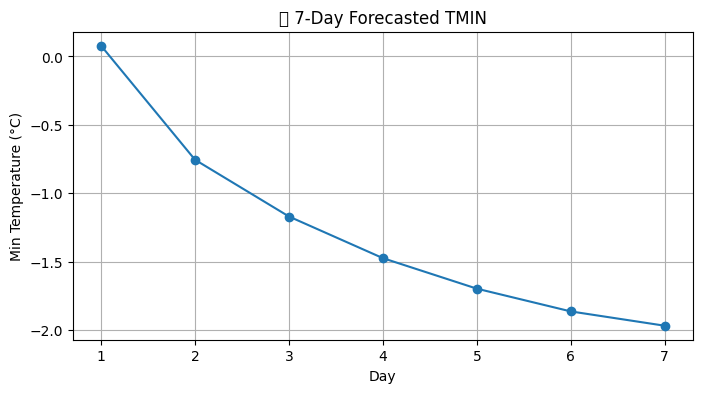

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_days+1), forecasted_tmin, marker='o')
plt.title('📆 7-Day Forecasted TMIN')
plt.xlabel('Day')
plt.ylabel('Min Temperature (°C)')
plt.grid(True)
plt.show()


📊 XGBoost Evaluation — MAE: 0.62 | RMSE: 0.81


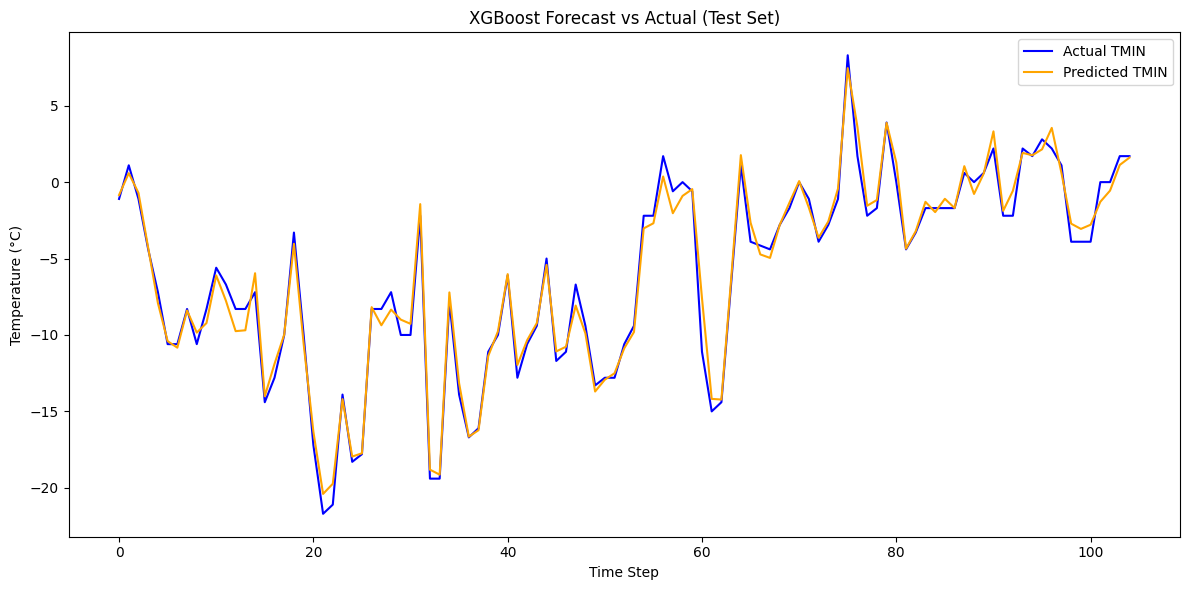

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# 1️⃣ Load data
df = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
df = df[df['Station_ID'] == 'USC00279278']
df = df.dropna().sort_values('DATE')

# 2️⃣ Features & Target
#features = [
 #   'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
  #  'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'Seasonal_TMIN_Anomaly',
 #   'TMIN_Lag1', 'PRCP_Lag1', 'Cumulative_Precipitation_7',
 #   'Day_of_Year', 'Month'
#]

features = [
    'TMAX', 'PRCP', 'SNOW', 'SNWD',
    'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30',
    'Seasonal_TMIN_Anomaly', 'TMIN_Lag1', 'PRCP_Lag1',
    'Cumulative_Precipitation_7', 'Day_of_Year', 'Month'
]

target = 'TMIN'

# 3️⃣ Split: train (<= year -3), val/test (last 3 years)
df['DATE'] = pd.to_datetime(df['DATE'])
df['Year'] = df['DATE'].dt.year

max_year = df['Year'].max()
train = df[df['Year'] <= max_year - 3]
val = df[df['Year'].isin([max_year - 2, max_year - 1])]
test = df[df['Year'] == max_year]

X_train, y_train = train[features], train[target]
X_val, y_val = val[features], val[target]
X_test, y_test = test[features], test[target]

# 4️⃣ Scaling (optional for XGBoost but good for consistency)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# 5️⃣ Train XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train_scaled, y_train)

# 6️⃣ Predict
y_pred = xgb.predict(X_test_scaled)

# 7️⃣ Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"📊 XGBoost Evaluation — MAE: {mae:.2f} | RMSE: {rmse:.2f}")

# 8️⃣ Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual TMIN', color='blue')
plt.plot(y_pred, label='Predicted TMIN', color='orange')
plt.title('XGBoost Forecast vs Actual (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# Get LSTM test predictions
y_lstm_pred_scaled = best_model.predict(X_test_seq)
y_lstm_pred = scaler_y.inverse_transform(y_lstm_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1))  # actual TMIN

# Get XGBoost test predictions
y_xgb_pred = xgb.predict(X_test_scaled).reshape(-1, 1)

# Align lengths (LSTM uses sequence trimming)
start = len(y_xgb_pred) - len(y_lstm_pred)
y_actual = y_actual[start:]
y_xgb_pred = y_xgb_pred[start:]


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step 


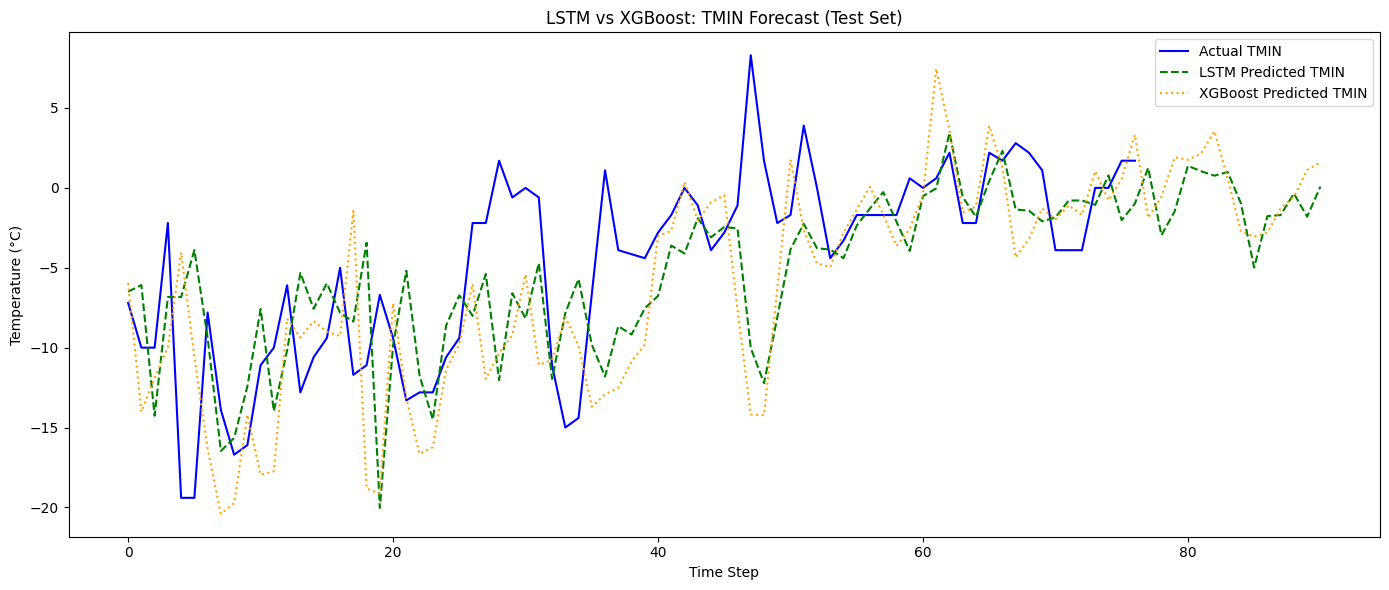

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(y_actual, label='Actual TMIN', color='blue')
plt.plot(y_lstm_pred, label='LSTM Predicted TMIN', color='green', linestyle='dashed')
plt.plot(y_xgb_pred, label='XGBoost Predicted TMIN', color='orange', linestyle='dotted')
plt.title('LSTM vs XGBoost: TMIN Forecast (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd

# Load your current data
df = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')

# Ensure date format
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')

# Add SNOW lag and rolling features
df['SNOW_Lag1'] = df['SNOW'].shift(1)
df['Rolling_Mean_SNOW_7'] = df['SNOW'].rolling(window=7).mean()

# Drop any resulting NA values
df.dropna(inplace=True)

# Save the updated file
df.to_csv('/workspaces/BlizzardX/Data/feature_data.csv', index=False)

print("✅ Updated feature_data.csv with SNOW lag/rolling features.")


✅ Updated feature_data.csv with SNOW lag/rolling features.


📊 XGBoost SNOW — MAE: 6.15 | RMSE: 16.98


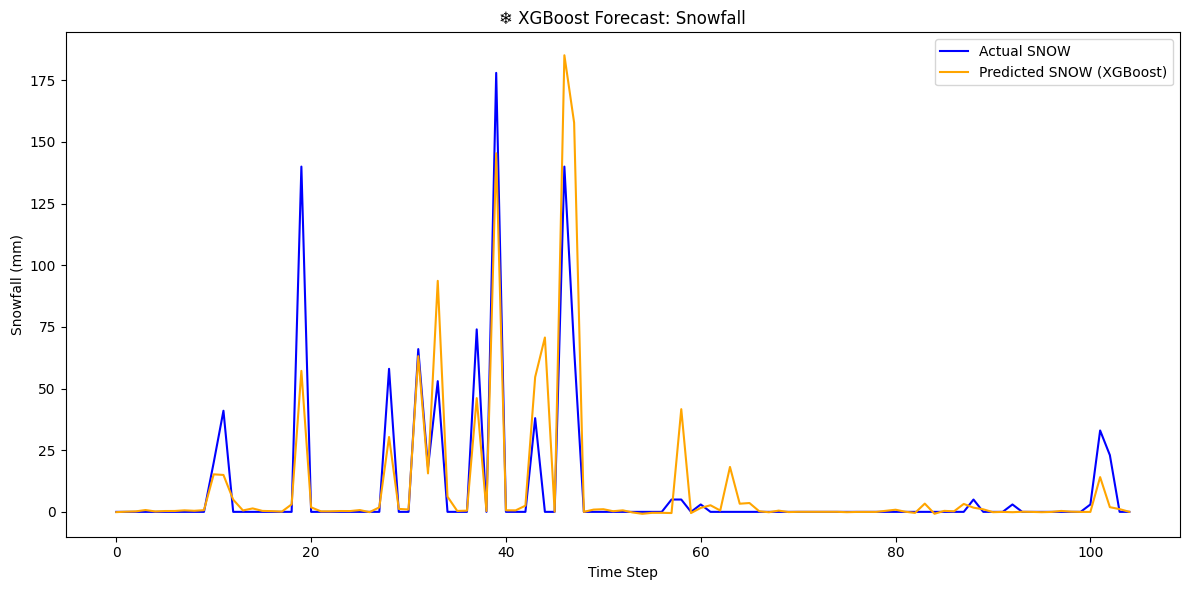

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# 1️⃣ Load Data
df = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
df = df[df['Station_ID'] == 'USC00279278']
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').dropna()
df['Year'] = df['DATE'].dt.year

# 2️⃣ Target & Features
target = 'SNOW'
features = [
    'TMAX', 'TMIN', 'PRCP', 'SNWD',
    'Rolling_Mean_SNOW_7', 'SNOW_Lag1',
    'Cumulative_Precipitation_7', 'Day_of_Year', 'Month'
]

# 3️⃣ Time Split
max_year = df['Year'].max()
train = df[df['Year'] <= max_year - 3]
val = df[df['Year'].isin([max_year - 2, max_year - 1])]
test = df[df['Year'] == max_year]

X_train, y_train = train[features], train[target]
X_val, y_val = val[features], val[target]
X_test, y_test = test[features], test[target]

# 4️⃣ Scale
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 5️⃣ Train XGBoost
model = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_train_scaled, y_train)

# 6️⃣ Predict & Evaluate
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"📊 XGBoost SNOW — MAE: {mae:.2f} | RMSE: {rmse:.2f}")

# 7️⃣ Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual SNOW', color='blue')
plt.plot(y_pred, label='Predicted SNOW (XGBoost)', color='orange')
plt.title('❄️ XGBoost Forecast: Snowfall')
plt.xlabel('Time Step')
plt.ylabel('Snowfall (mm)')
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
# Trim y_actual and y_xgb_pred to match LSTM length
trim_length = len(y_lstm_pred)
y_actual_trimmed = y_actual[-trim_length:]
y_xgb_pred_trimmed = y_xgb_pred[-trim_length:]


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lstm = mean_absolute_error(y_actual_trimmed, y_lstm_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_actual_trimmed, y_lstm_pred))

mae_xgb = mean_absolute_error(y_actual_trimmed, y_xgb_pred_trimmed)
rmse_xgb = np.sqrt(mean_squared_error(y_actual_trimmed, y_xgb_pred_trimmed))

print(f"📊 LSTM — MAE: {mae_lstm:.2f}, RMSE: {rmse_lstm:.2f}")
print(f"📊 XGBoost — MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}")




ValueError: Found input variables with inconsistent numbers of samples: [77, 91]

In [26]:
print("y_lstm_pred:", len(y_lstm_pred))
print("y_actual_trimmed:", len(y_actual_trimmed))
print("y_xgb_pred_trimmed:", len(y_xgb_pred_trimmed))


y_lstm_pred: 91
y_actual_trimmed: 77
y_xgb_pred_trimmed: 91


In [27]:
# Align all to LSTM prediction length
trim_len = len(y_lstm_pred)
y_actual_trimmed = y_actual[-trim_len:].reshape(-1)
y_xgb_pred_trimmed = y_xgb_pred[-trim_len:].reshape(-1)
y_lstm_pred = y_lstm_pred.reshape(-1)  # ensure shape compatibility


In [28]:
mae_lstm = mean_absolute_error(y_actual_trimmed, y_lstm_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_actual_trimmed, y_lstm_pred))

mae_xgb = mean_absolute_error(y_actual_trimmed, y_xgb_pred_trimmed)
rmse_xgb = np.sqrt(mean_squared_error(y_actual_trimmed, y_xgb_pred_trimmed))

print(f"✅ LSTM — MAE: {mae_lstm:.2f}, RMSE: {rmse_lstm:.2f}")
print(f"✅ XGBoost — MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}")


ValueError: Found input variables with inconsistent numbers of samples: [77, 91]

In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input
import keras_tuner as kt
from keras_tuner import Objective
import matplotlib.pyplot as plt
import tensorflow as tf

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 1️⃣ Load data
df = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
df['DATE'] = pd.to_datetime(df['DATE'])
df = df[df['Station_ID'] == 'USC00279278'].dropna().sort_values('DATE')
df['Year'] = df['DATE'].dt.year

# 2️⃣ Set target & feature columns
target = 'SNOW'
initial_features = [
    'TMAX', 'TMIN', 'PRCP', 'SNWD',
    'Rolling_Mean_SNOW_7', 'SNOW_Lag1',
    'Cumulative_Precipitation_7', 'Day_of_Year', 'Month'
]

# 3️⃣ Feature selection using ExtraTrees
X_feat_check = df[initial_features]
y_feat_check = df[target]
etr = ExtraTreesRegressor(n_estimators=100, random_state=42)
etr.fit(X_feat_check, y_feat_check)
importances = etr.feature_importances_
filtered_features = pd.Series(importances, index=initial_features)
filtered_features = filtered_features[filtered_features > 0.02].index.tolist()

# 4️⃣ Train/Val/Test split
max_year = df['Year'].max()
train = df[df['Year'] <= max_year - 3]
val = df[df['Year'].isin([max_year - 2, max_year - 1])]
test = df[df['Year'] == max_year]

X_train, y_train = train[filtered_features], train[target]
X_val, y_val = val[filtered_features], val[target]
X_test, y_test = test[filtered_features], test[target]

# 5️⃣ Scale features and target
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# 6️⃣ Create sequences
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

seq_len = 14
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_len)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, seq_len)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_len)

# 7️⃣ Define and tune LSTM model
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(seq_len, len(filtered_features))))
    for i in range(hp.Int("num_lstm_layers", 1, 2)):
        model.add(LSTM(units=hp.Int(f"lstm_units_{i}", 32, 128, step=32),
                       return_sequences=(i != hp.get("num_lstm_layers") - 1)))
        model.add(Dropout(hp.Float(f"dropout_{i}", 0.1, 0.3, step=0.1)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])),
                  loss='mse', metrics=['mae'])
    return model

tuner = kt.BayesianOptimization(
    build_model,
    objective=Objective("val_loss", direction="min"),
    max_trials=8,
    executions_per_trial=1,
    directory="lstm_tuner_snow",
    project_name="snow_lstm"
)

train_ds = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)).batch(16).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(16).prefetch(tf.data.AUTOTUNE)

tuner.search(train_ds, validation_data=val_ds, epochs=30,
             callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=1)

# 8️⃣ Final model
best_model = tuner.get_best_models(num_models=1)[0]
eval_results = best_model.evaluate(X_test_seq, y_test_seq)
print("📊 LSTM Snow Evaluation:", dict(zip(best_model.metrics_names, eval_results)))


Trial 8 Complete [00h 00m 37s]
val_loss: 0.5188735127449036

Best val_loss So Far: 0.5163121223449707
Total elapsed time: 00h 07m 48s


/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.5988 - mae: 0.6842 
📊 LSTM Snow Evaluation: {'loss': 1.1688154935836792, 'compile_metrics': 0.5436477661132812}
